# 06 · Decomposition & Attribution

The v0.3 milestone answers *why* emissions changed, not just *whether* they did. It uses the **Kaya identity** with a **Log Mean Divisia Index (LMDI)** decomposition, an emissions-intensity decomposition, and a set of transparent transition indicators.

LMDI is *exact*: the per-factor contributions sum to the actual change (the residual is zero up to floating point), which keeps the attribution fully auditable.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse, load_transition_mart
from carbon_transition_duckdb.risk.scoring import filter_entities
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
    build_duckdb_lakehouse(
        ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
    )

mart = filter_entities(load_transition_mart(DB_PATH))
years = (int(mart["year"].min()), int(mart["year"].max()))
print(f"Mart: {mart.shape[0]} rows, {mart['country'].nunique()} countries, "
      f"{years[0]}-{years[1]}")


Mart: 75 rows, 5 countries, 2010-2024


## 1. Kaya identity decomposition

With no GDP column the synthetic data uses the three-factor form:

$$\Delta CO_2 = \text{population} + \text{energy per capita} + \text{carbon intensity of energy}$$

Each term is the additive LMDI contribution to the total change.

In [3]:
from carbon_transition_duckdb.decomposition import kaya_decomposition_frame

kaya = kaya_decomposition_frame(mart, years[0], years[1])
kaya

,country,co2_start,co2_end,delta_co2,population_effect,energy_per_capita_effect,carbon_intensity_effect,residual
0,Atlantis,60.4976,52.6251,-7.8725,6.7014,1.7374,-16.3112,0.0
1,Borealia,175.7187,157.3759,-18.3428,19.7444,5.1911,-43.2784,0.0
2,Cyrenia,19.1148,9.1096,-10.0052,1.6020,0.6502,-12.2575,0.0
3,Deltora,260.0812,254.4571,-5.6241,30.5293,5.3298,-41.4832,0.0
4,Estavia,42.2278,27.0308,-15.1970,4.0427,1.9959,-21.2356,-0.0


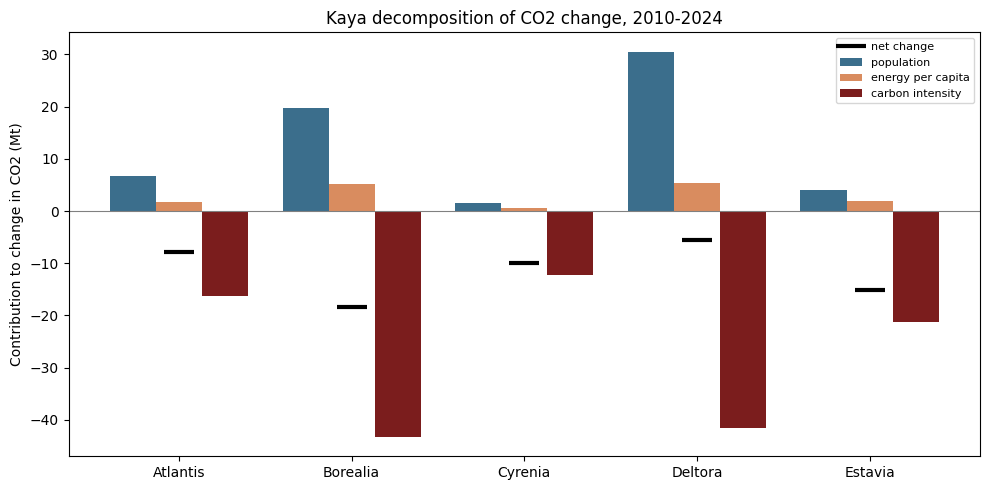

In [4]:
effects = [c for c in kaya.columns if c.endswith('_effect')]
labels = [e.replace('_effect', '').replace('_', ' ') for e in effects]
x = list(range(len(kaya)))
width = 0.8 / len(effects)
colors = ['#3b6e8c', '#d98c5f', '#7b1d1d']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (eff, label) in enumerate(zip(effects, labels, strict=True)):
    offsets = [xx + i * width for xx in x]
    ax.bar(offsets, kaya[eff], width=width, label=label, color=colors[i % len(colors)])
centers = [xx + width * (len(effects) - 1) / 2 for xx in x]
ax.plot(centers, kaya['delta_co2'], 'k_', markersize=22, markeredgewidth=3,
        label='net change')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xticks(centers)
ax.set_xticklabels(kaya['country'])
ax.set_ylabel('Contribution to change in CO2 (Mt)')
ax.set_title(f'Kaya decomposition of CO2 change, {years[0]}-{years[1]}')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Falling carbon intensity dominates the decline everywhere, while population growth pushes emissions up. The decomposition is exact:

In [5]:
print('Max absolute residual:', kaya['residual'].abs().max())

Max absolute residual:

 0.0


## 2. Emissions-intensity decomposition

Splitting the change in **CO2 per capita** isolates *using less energy per person* from *cleaning up the energy mix*.

In [6]:
from carbon_transition_duckdb.decomposition import intensity_decomposition_frame

intensity = intensity_decomposition_frame(mart, years[0], years[1])
intensity

,country,co2_per_capita_start,co2_per_capita_end,delta,energy_per_capita_effect,carbon_intensity_effect,residual
0,Atlantis,0.0,0.0,-0.0,0.0,-0.0,-0.0
1,Borealia,0.0,0.0,-0.0,0.0,-0.0,-0.0
2,Cyrenia,0.0,0.0,-0.0,0.0,-0.0,0.0
3,Deltora,0.0,0.0,-0.0,0.0,-0.0,0.0
4,Estavia,0.0,0.0,-0.0,0.0,-0.0,-0.0


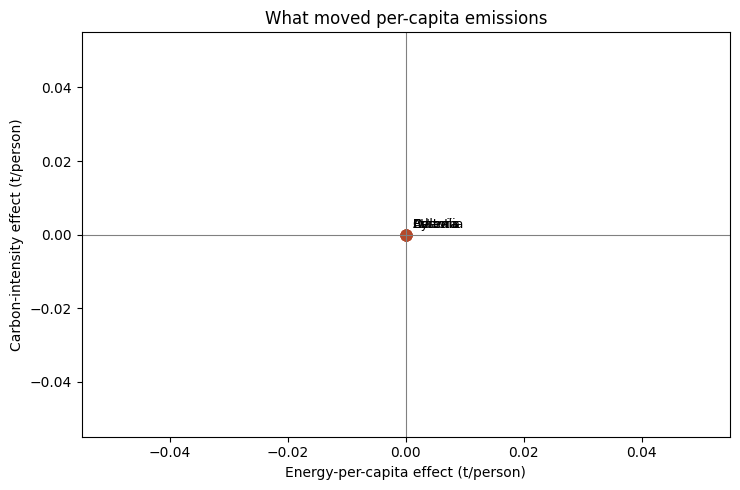

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(intensity['energy_per_capita_effect'],
           intensity['carbon_intensity_effect'], s=60, color='#b5482a')
for _, row in intensity.iterrows():
    ax.annotate(row['country'],
                (row['energy_per_capita_effect'], row['carbon_intensity_effect']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Energy-per-capita effect (t/person)')
ax.set_ylabel('Carbon-intensity effect (t/person)')
ax.set_title('What moved per-capita emissions')
fig.tight_layout()
plt.show()

## 3. Transition indicators

Derived, transparent indicators for the electricity mix, fossil lock-in, and an industrial proxy. The **fossil lock-in index** is high when the fossil share is large *and* falling slowly.

In [8]:
from carbon_transition_duckdb.decomposition import transition_indicators

indicators = transition_indicators(mart, years[0], years[1])
indicators[['country', 'renewables_share_elec_change', 'fossil_share_end',
            'fossil_annual_decline', 'fossil_lockin_index',
            'carbon_intensity_change']]

,country,renewables_share_elec_change,fossil_share_end,fossil_annual_decline,fossil_lockin_index,carbon_intensity_change
0,Deltora,-3.443,83.918,0.276,65.791,-0.027177
1,Borealia,13.904,75.126,0.496,50.222,-0.045825
2,Atlantis,15.886,61.186,0.977,30.953,-0.047751
3,Estavia,25.780,30.815,1.535,12.153,-0.076035
4,Cyrenia,32.032,21.346,1.667,8.004,-0.095170


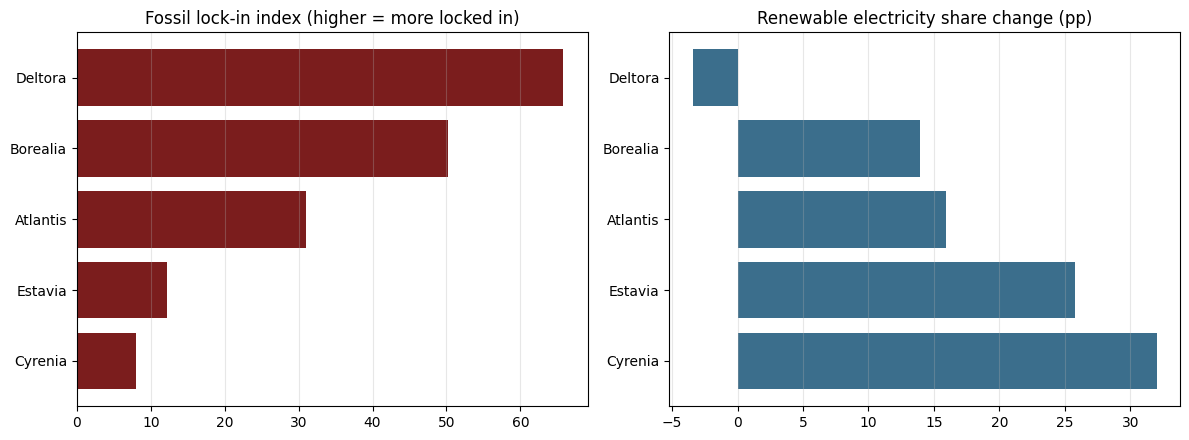

In [9]:
ordered = indicators.sort_values('fossil_lockin_index')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(ordered['country'], ordered['fossil_lockin_index'], color='#7b1d1d')
axes[0].set_title('Fossil lock-in index (higher = more locked in)')
axes[1].barh(ordered['country'], ordered['renewables_share_elec_change'],
             color='#3b6e8c')
axes[1].set_title('Renewable electricity share change (pp)')
for ax in axes:
    ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
plt.show()

## Takeaways

- The Kaya/LMDI decomposition attributes every megatonne of change to population, energy use, and carbon intensity -- exactly, with no residual.
- The intensity decomposition separates *demand* (energy per capita) from *supply* (carbon intensity) drivers of per-capita emissions.
- Lock-in and electricity-mix indicators flag where fossil dependence is persistent versus where the transition is moving fastest.
- All of these are transparent functions of the mart -- screening signals for deeper review, not causal claims.